# Phase 4 & 5: The Challenger Model — Non-Linear LightGBM & SHAP Explainability
## Project: Institutional Credit Risk Scoring Pipeline

### 1. Objective
This notebook introduces our "Challenger" model built on modern machine learning architecture. Our goal is to determine if allowing non-linear interactions and shifting away from manual binning can deliver a significant performance "lift" (increased separation of risk) over our traditional Champion scorecard.

### 2. Algorithm: LightGBM Tree Ensemble
Unlike the linear scorecard, **LightGBM** ingests the raw, un-binned continuous features (`annual_inc`, `int_rate`, `loan_amnt`) and raw categorical variables (`grade`, `purpose`). This allows the gradient-boosted trees to capture:
* Highly granular mathematical split boundaries.
* Native feature interactions (e.g., how risk multiplies when low income compounds with massive loan requests) without requiring manual interaction engineering.

### 3. The Champion vs. Challenger Audit
We run a head-to-head performance comparison using the **Gini Coefficient** and **KS Statistic** calculated on the exact same underlying applicant data. Any positive difference in metrics is evaluated as the "financial lift"—allowing the bank to quantify exactly how many millions of dollars in default write-offs would be saved by deploying the machine learning framework over the linear model.

### 4. Regulatory Compliance Layer (SHAP)
Because tree ensembles operate as "black boxes," they natively violate the **Equal Credit Opportunity Act (ECOA)** and **Fair Credit Reporting Act (FCRA)**, which require banks to provide clear reasons for loan denials.

To bridge this regulatory gap, we implement **SHAP (SHapley Additive exPlanations)** values derived from cooperative game theory. This layer explains individual predictions locally, allowing us to isolate the exact top drivers of risk and automatically print legally binding **Adverse Action Notice Reason Codes** for any rejected applicant.

In [1]:
import os
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, roc_curve

PROCESSED_DATA_DIR = "data/processed"
# Reload original filtered records to leverage unbinned continuous values
df_raw_base = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "01_cleaned_cohort.csv.gz"), compression='gzip')

# LEAKAGE CONTROL — must mirror notebook 02. total_rec_prncp and recoveries are
# post-default outcomes; feeding them to the challenger is what previously drove an
# absurd KS ~99.5. A fair champion-vs-challenger duel requires the SAME information set.
leakage_cols = ['total_rec_prncp', 'recoveries']

ml_features = [col for col in df_raw_base.columns
               if col not in ['target', 'loan_status'] + leakage_cols]
X_ml = df_raw_base[ml_features].copy()
y_ml = df_raw_base['target']

categorical_cols = X_ml.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
    X_ml[col] = X_ml[col].astype('category')

print(f"Challenger machine learning configuration finalized.")
print(f"Dropped leakage features: {leakage_cols}")
print(f"Ingested {len(ml_features)} features ({len(categorical_cols)} categorical, {len(ml_features)-len(categorical_cols)} continuous).")

C:\Users\steph\AppData\Local\Temp\ipykernel_3680\1855381213.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_ml.select_dtypes(include=['object', 'category']).columns.tolist()


Challenger machine learning configuration finalized.
Dropped leakage features: ['total_rec_prncp', 'recoveries']
Ingested 47 features (9 categorical, 38 continuous).


In [2]:
from sklearn.model_selection import train_test_split

# Same 70/30 seed as notebook 03 — apples-to-apples comparison
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_ml, y_ml, test_size=0.30, random_state=42, stratify=y_ml
)

challenger_lgb = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

challenger_lgb.fit(X_train_ml, y_train_ml)

# Predictions on the held-out test set only
df_test_ml = X_test_ml.copy()
df_test_ml['target']   = y_test_ml.values
df_test_ml['prob_lgb'] = challenger_lgb.predict_proba(X_test_ml)[:, 1]

print("Challenger model trained. Predictions stored on held-out test set.")

Challenger model trained. Predictions stored on held-out test set.


In [3]:
import json
import pickle

ARTIFACTS_DIR = os.path.join(PROCESSED_DATA_DIR, "model_artifacts")

# Load champion metrics written by notebook 03 — no magic numbers
with open(os.path.join(ARTIFACTS_DIR, "champion_metrics.json"), "r") as f:
    champion_metrics = json.load(f)
champion_gini = champion_metrics['gini']
champion_ks   = champion_metrics['ks']

# Challenger metrics on the same held-out test set
auc_lgb  = roc_auc_score(y_test_ml, df_test_ml['prob_lgb'])
gini_lgb = 2 * auc_lgb - 1

fpr_lgb, tpr_lgb, _ = roc_curve(y_test_ml, df_test_ml['prob_lgb'])
ks_lgb = max(tpr_lgb - fpr_lgb) * 100

print("=== CHAMPION vs. CHALLENGER (both out-of-sample) ===")
print(f"Scorecard Gini : {champion_gini:.4f} | LightGBM Gini : {gini_lgb:.4f} | Lift: {gini_lgb - champion_gini:+.4f}")
print(f"Scorecard KS   : {champion_ks:.2f}%  | LightGBM KS   : {ks_lgb:.2f}%  | Lift: {ks_lgb - champion_ks:+.2f}%")

# Save challenger artifact for app.py
with open(os.path.join(ARTIFACTS_DIR, "challenger_lgb.pkl"), "wb") as f:
    pickle.dump(challenger_lgb, f)

=== CHAMPION vs. CHALLENGER (both out-of-sample) ===
Scorecard Gini : 0.4291 | LightGBM Gini : 0.4420 | Lift: +0.0129
Scorecard KS   : 31.07%  | LightGBM KS   : 32.06%  | Lift: +0.99%


C:\Users\steph\PycharmProjects\Home-Credit-Risk\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


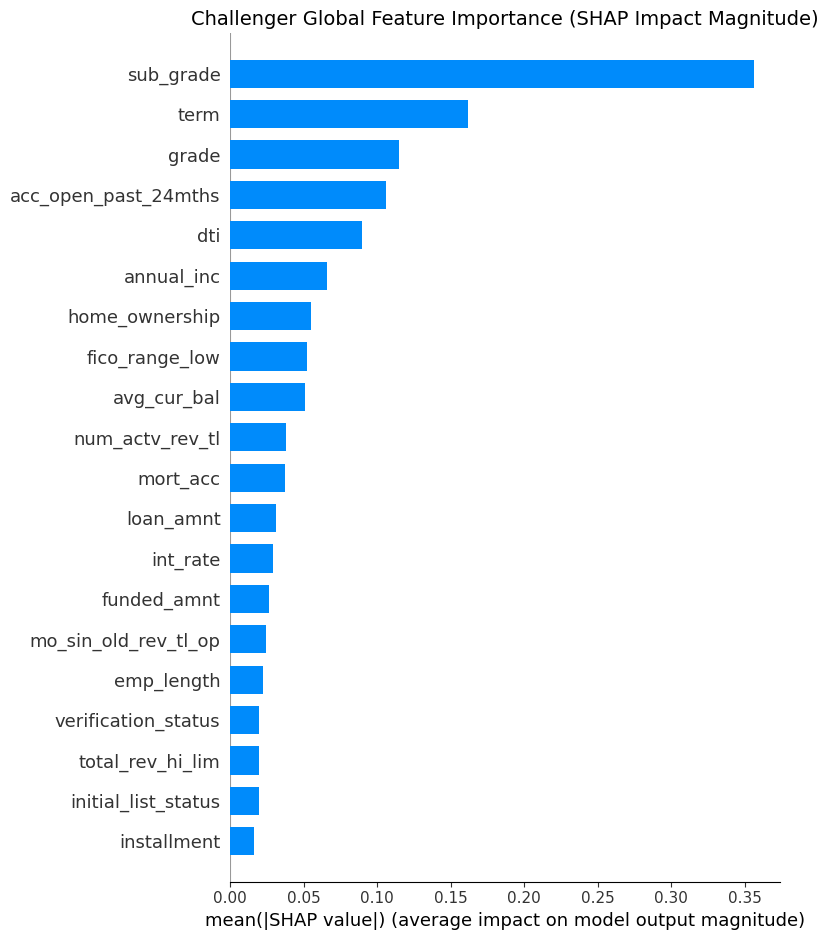

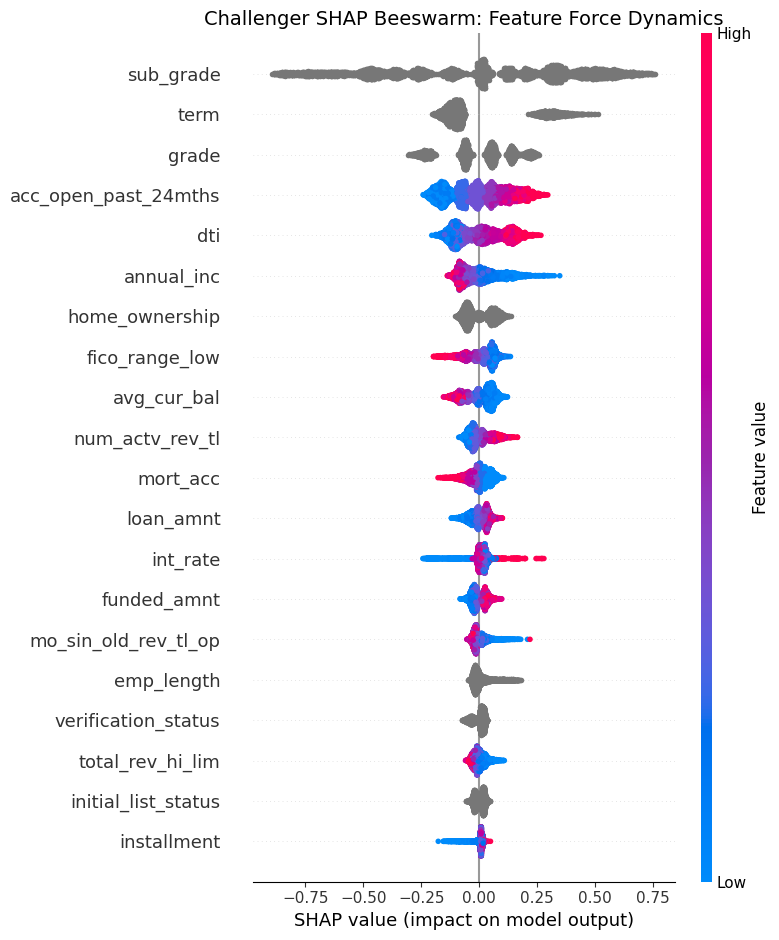

In [4]:
import warnings
import shap
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message=".*LightGBM binary classifier with TreeExplainer.*")

# Sample from test set — 5000 rows is standard practice for SHAP plots
shap_sample = X_test_ml.sample(n=min(5000, len(X_test_ml)), random_state=42)

explainer = shap.TreeExplainer(challenger_lgb)

# Modern API: explainer(X) returns an Explanation object; .values is always the raw array
shap_explanation  = explainer(shap_sample)
shap_values_target = shap_explanation.values   # shape: (n_samples, n_features)

plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values_target, shap_sample, plot_type="bar", show=False)
plt.title("Challenger Global Feature Importance (SHAP Impact Magnitude)", fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values_target, shap_sample, show=False)
plt.title("Challenger SHAP Beeswarm: Feature Force Dynamics", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# Highest-risk defaulter in the test set
high_risk_idx    = df_test_ml[df_test_ml['target'] == 1]['prob_lgb'].idxmax()
borrower_profile = X_test_ml.loc[high_risk_idx]

# Run explainer on this single row directly — unambiguous, no index arithmetic
borrower_shap = explainer(X_test_ml.loc[[high_risk_idx]]).values[0]

adverse_action_df = pd.DataFrame({
    'Feature'    : ml_features,
    'Value'      : borrower_profile.values,
    'SHAP_Impact': borrower_shap
}).sort_values(by='SHAP_Impact', ascending=False)

print("=== REGULATORY ADVERSE ACTION NOTICE GENERATOR ===")
print(f"Target Record Index          : Row {high_risk_idx}")
print(f"Computed Default Probability : {df_test_ml.loc[high_risk_idx, 'prob_lgb']:.2%}\n")
print("Top Adverse Reason Codes (ECOA/FCRA):")
print("--------------------------------------")

rank = 1
for _, row in adverse_action_df.iterrows():
    if row['SHAP_Impact'] > 0 and rank <= 5:   # regulators typically require top 4–5 reasons
        print(f"Reason {rank}: '{row['Feature']}' = [{row['Value']}]  →  log-odds contribution: +{row['SHAP_Impact']:.4f}")
        rank += 1

=== REGULATORY ADVERSE ACTION NOTICE GENERATOR ===
Target Record Index          : Row 438354
Computed Default Probability : 72.90%

Top Adverse Reason Codes (ECOA/FCRA):
--------------------------------------
Reason 1: 'sub_grade' = [F3]  →  log-odds contribution: +0.6729
Reason 2: 'term' = [ 60 months]  →  log-odds contribution: +0.3617
Reason 3: 'acc_open_past_24mths' = [16.0]  →  log-odds contribution: +0.2544
Reason 4: 'grade' = [F]  →  log-odds contribution: +0.2437
Reason 5: 'dti' = [36.48]  →  log-odds contribution: +0.2157
